In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [6]:
import sys
print(sys.executable)

C:\Users\kumar\AppData\Local\Programs\Python\Python313\python.exe


In [8]:
!{sys.executable} -m pip install psycopg2-binary

In [10]:
import psycopg2

In [15]:
import psycopg2

conn = psycopg2.connect(
    host="localhost",
    database="scm",   # make sure this exists
    user="postgres",
    password="1234",  # same password you just set
    port="5432"
)

print("Connected successfully")

Connected successfully


In [17]:
cur = conn.cursor()

cur.execute("SELECT datname FROM pg_database;")
print(cur.fetchall())

[('postgres',), ('IPL',), ('template1',), ('template0',), ('lenskart',), ('dtdc',), ('R_Data_MNC',), ('vehicle_sales',), ('car_sales_data',), ('amazon_sales',), ('scm',)]


In [19]:
cur.execute("SELECT * FROM supply_chain_data")
rows = cur.fetchall()

for row in rows:
    print(row)

('haircare', 'SKU0', 69.80800554211577, '55', 802, 8661.996792392383, 'Non-binary', 58, 7, 96, 4, 'Carrier B', 2.956572139430807, 'Supplier 3', 'Mumbai', 29, 215, 29, 46.27987924050832, 'Pending', 0.22641036084992516, 'Road', 'Route B', 187.75207545920392)
('skincare', 'SKU1', 14.843523275084339, '95', 736, 7460.900065445849, 'Female', 53, 30, 37, 2, 'Carrier A', 9.71657477143131, 'Supplier 3', 'Mumbai', 23, 517, 30, 33.61676895373, 'Pending', 4.854068026388706, 'Road', 'Route B', 503.0655791496692)
('haircare', 'SKU2', 11.319683293090566, '34', 8, 9577.74962586873, 'Unknown', 1, 10, 88, 2, 'Carrier B', 8.054479261732155, 'Supplier 1', 'Mumbai', 12, 971, 27, 30.688019348284204, 'Pending', 4.580592619199229, 'Air', 'Route C', 141.92028177151906)
('skincare', 'SKU3', 61.163343016437736, '68', 83, 7766.836425685233, 'Non-binary', 23, 13, 59, 6, 'Carrier C', 1.7295685635434288, 'Supplier 5', 'Kolkata', 24, 937, 18, 35.62474139712503, 'Fail', 4.74664862064775, 'Rail', 'Route A', 254.7761592

In [24]:
import pandas as pd

# Get column names
colnames = [desc[0] for desc in cur.description]

# Convert to DataFrame
df = pd.DataFrame(rows, columns=colnames)

df.head()

,product_type,sku,price,availability,number_of_products_sold,revenue_generated,customer_demographics,stock_levels,lead_times,order_quantities,...,location,lead_time,production_volumes,manufacturing_lead_time,manufacturing_costs,inspection_results,defect_rates,transportation_modes,routes,costs
0,haircare,SKU0,69.808006,55,802,8661.996792,Non-binary,58,7,96,...,Mumbai,29,215,29,46.279879,Pending,0.226410,Road,Route B,187.752075
1,skincare,SKU1,14.843523,95,736,7460.900065,Female,53,30,37,...,Mumbai,23,517,30,33.616769,Pending,4.854068,Road,Route B,503.065579
2,haircare,SKU2,11.319683,34,8,9577.749626,Unknown,1,10,88,...,Mumbai,12,971,27,30.688019,Pending,4.580593,Air,Route C,141.920282
3,skincare,SKU3,61.163343,68,83,7766.836426,Non-binary,23,13,59,...,Kolkata,24,937,18,35.624741,Fail,4.746649,Rail,Route A,254.776159
4,skincare,SKU4,4.805496,26,871,2686.505152,Non-binary,5,3,56,...,Delhi,5,414,3,92.065161,Fail,3.145580,Air,Route A,923.440632


In [26]:
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 24 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   product_type             100 non-null    object 
 1   sku                      100 non-null    object 
 2   price                    100 non-null    float64
 3   availability             100 non-null    object 
 4   number_of_products_sold  100 non-null    int64  
 5   revenue_generated        100 non-null    float64
 6   customer_demographics    100 non-null    object 
 7   stock_levels             100 non-null    int64  
 8   lead_times               100 non-null    int64  
 9   order_quantities         100 non-null    int64  
 10  shipping_times           100 non-null    int64  
 11  shipping_carriers        100 non-null    object 
 12  shipping_costs           100 non-null    float64
 13  supplier_name            100 non-null    object 
 14  location                 10

,price,number_of_products_sold,revenue_generated,stock_levels,lead_times,order_quantities,shipping_times,shipping_costs,lead_time,production_volumes,manufacturing_lead_time,manufacturing_costs,defect_rates,costs
count,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.00000,100.000000,100.000000,100.000000
mean,49.462461,460.990000,5776.048187,47.770000,15.960000,49.220000,5.750000,5.548149,17.080000,567.840000,14.77000,47.266693,2.277158,529.245782
std,31.168193,303.780074,2732.841744,31.369372,8.785801,26.784429,2.724283,2.651376,8.846251,263.046861,8.91243,28.982841,1.461366,258.301696
min,1.699976,8.000000,1061.618523,0.000000,1.000000,1.000000,1.000000,1.013487,1.000000,104.000000,1.00000,1.085069,0.018608,103.916248
25%,19.597823,184.250000,2812.847151,16.750000,8.000000,26.000000,3.750000,3.540248,10.000000,352.000000,7.00000,22.983299,1.009650,318.778455
50%,51.239831,392.500000,6006.352023,47.500000,17.000000,52.000000,6.000000,5.320534,18.000000,568.500000,14.00000,45.905622,2.141863,520.430444
75%,77.198228,704.250000,8253.976921,73.000000,24.000000,71.250000,8.000000,7.601695,25.000000,797.000000,23.00000,68.621026,3.563995,763.078231
max,99.171329,996.000000,9866.465458,100.000000,30.000000,96.000000,10.000000,9.929816,30.000000,985.000000,30.00000,99.466109,4.939255,997.413450


In [28]:
print("Total Revenue:", df['revenue_generated'].sum())
print("Total Orders:", df['number_of_products_sold'].sum())
print("Avg Defect Rate:", df['defect_rates'].mean())

Total Revenue: 577604.8187380086
Total Orders: 46099
Avg Defect Rate: 2.27715799273961


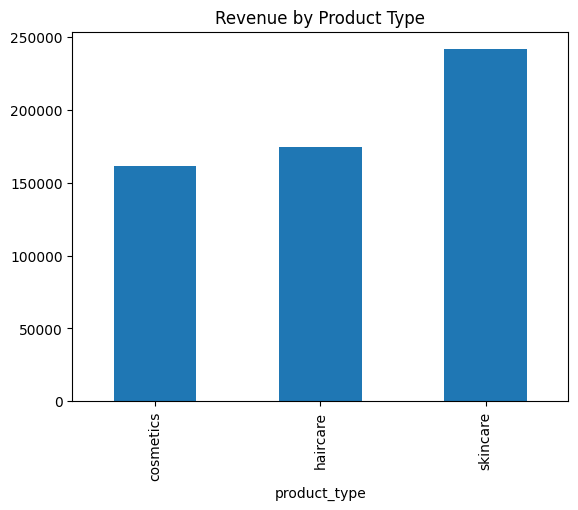

In [30]:
import matplotlib.pyplot as plt

df.groupby('product_type')['revenue_generated'].sum().plot(kind='bar')
plt.title("Revenue by Product Type")
plt.show()

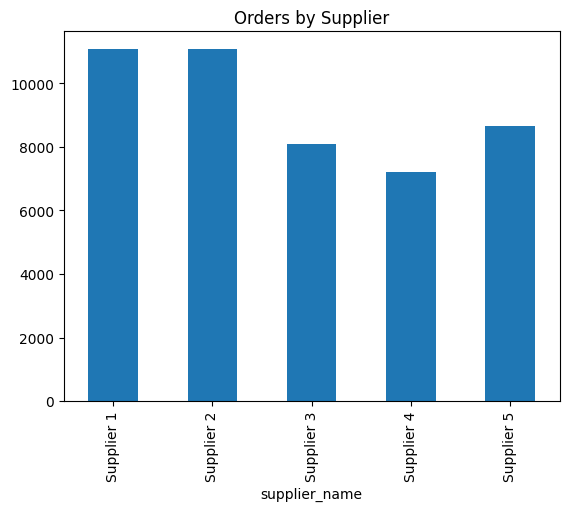

In [32]:
df.groupby('supplier_name')['number_of_products_sold'].sum().plot(kind='bar')
plt.title("Orders by Supplier")
plt.show()

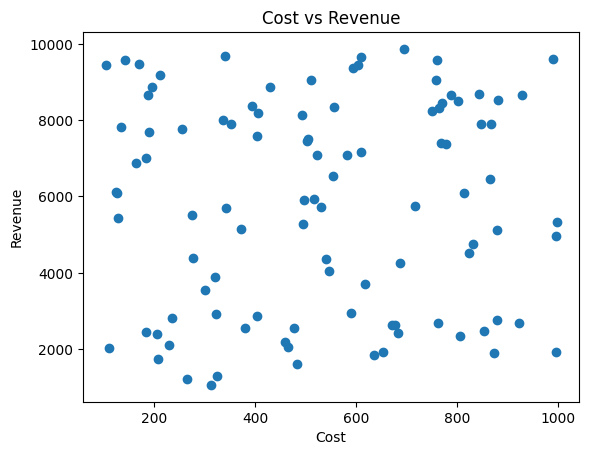

In [35]:
plt.scatter(df['costs'], df['revenue_generated'])
plt.xlabel("Cost")
plt.ylabel("Revenue")
plt.title("Cost vs Revenue")
plt.show()

In [37]:
# Top 5 Products
df.sort_values(by='number_of_products_sold', ascending=False).head()

# High Cost Routes
df.groupby('routes')['costs'].sum().sort_values(ascending=False)

# Carrier Performance
df.groupby('shipping_carriers')['shipping_costs'].mean()

shipping_carriers
Carrier A    5.554923
Carrier B    5.509247
Carrier C    5.599292
Name: shipping_costs, dtype: float64